# Intervalos de Confianza para la Eficiencia de un Detector
---

Un detector de partículas tiene una eficiencia desconocida $\varepsilon$: la probabilidad de que detecte una partícula que efectivamente lo atraviesa. En cada experimento se lanzan $n = 32$ partículas y se registra el número $k$ de detecciones. La variable $k$ sigue una distribución binomial:
$$
k \sim B(n,\, \varepsilon)
$$
El estimador natural de $\varepsilon$ es $\hat{\varepsilon} = k/n$. El intervalo de confianza estándar de $\varepsilon$ con nivel de confianza 95% es
$$
\hat{\varepsilon} \pm 1.96\,\sqrt{\frac{\hat{\varepsilon}(1-\hat{\varepsilon})}{n}}
$$
donde $q = 1.96$ es el cuantil de la normal estándar para CL = 95%.

**Objetivos:**
- Simular 10 000 experimentos asumiendo $\varepsilon = 0.2$.
- Verificar si el intervalo cubre el verdadero $\varepsilon$ en cada caso.
- Estimar la cobertura real y comparar con el 95% nominal.
- Barrer $\varepsilon \in [0, 1]$ y graficar la cobertura en función de $\varepsilon$.
- Comparar con otro intervalo: $t \pm 1.96\sqrt{t(1-t)/n}$ con $t = (k+2)/(n+4)$.

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [96]:
# Parámetros del problema
n = 32        # partículas lanzadas por experimento
eps = 0.2       # eficiencia real del detector
sim = 10000     # número de experimentos simulados
q = 1.96      # cuantil normal para CL = 95%

In [97]:
# Simulamos las detecciones y calculamos el estimador con su error
k_val = np.random.binomial(n, eps, size=sim)
eps_hat = k_val / n
eps_hat_err = np.sqrt(eps_hat * (1 - eps_hat) / n)

In [98]:
# Calculamos la cobertura: fracción de experimentos en que el intervalo contiene eps
dentro = np.where(eps_hat >= eps - q * eps_hat_err, True, False)
cobertura = np.sum(dentro) / sim
print(f'Cobertura del intervalo: {cobertura*100:.2f}%')

Cobertura del intervalo: 90.90%


La cobertura obtenida es notablemente inferior al 95% nominal. Esto ocurre porque la aproximación normal de la binomial es pobre cuando $n$ es moderado y $\varepsilon$ está lejos de 0.5: el intervalo **no es exacto**.

Para ver en qué rangos de eficiencia el intervalo falla más, barremos $\varepsilon \in [0, 1]$.

In [99]:
# Barrido de eps en [0, 1] con paso 0.01
vector_eps = np.arange(0, 1.01, 0.01)

# Simulamos para cada valor de eps (vectorizado: eje 0 = eps, eje 1 = simulación)
val_sim = stats.binom.rvs(n, vector_eps[:, np.newaxis], size=(len(vector_eps), sim))

# Calculamos los intervalos de nivel de confianza de 95%
e_hat = val_sim / n
delta = q * np.sqrt(e_hat * (1 - e_hat) / n)
lim_up = e_hat + delta
lim_low = e_hat - delta

# Calculamos la probabilidad de cobertura
cond = (vector_eps[:, np.newaxis] > lim_low) & (vector_eps[:, np.newaxis] < lim_up)
coberturas = np.mean(cond, axis=1)

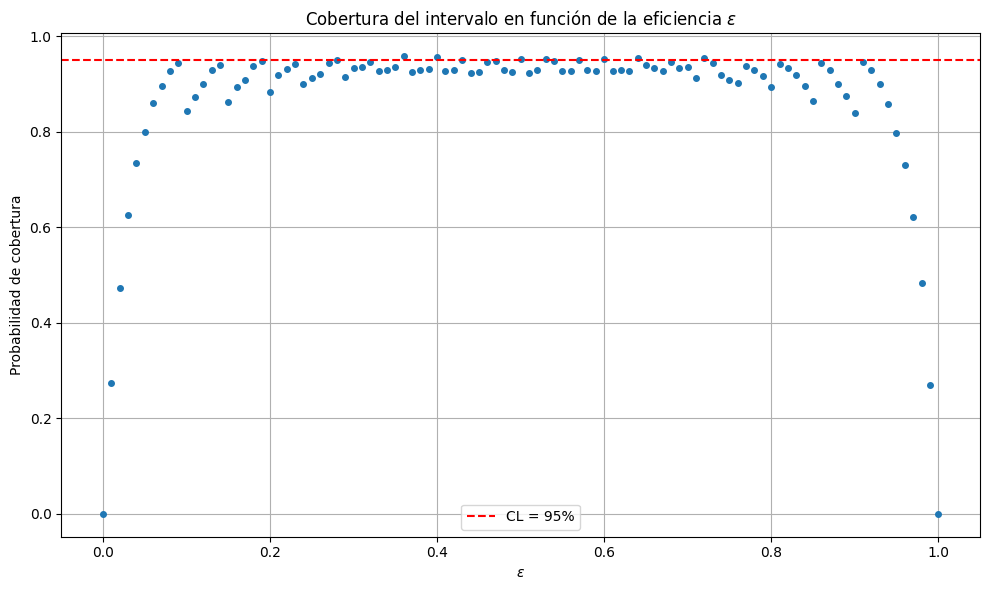

In [100]:
# Graficamos cobertura del intervalo de en función de eps
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_title('Cobertura del intervalo en función de la eficiencia $\\varepsilon$')
ax1.set_xlabel('$\\varepsilon$')
ax1.set_ylabel('Probabilidad de cobertura')
ax1.plot(vector_eps, coberturas, marker='o', linestyle='none', ms=4)
ax1.axhline(0.95, color='r', linestyle='--', label='CL = 95%')
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

La cobertura oscila fuertemente y cae por debajo de 95% en gran parte del rango, especialmente cerca de $\varepsilon \approx 0$ y $\varepsilon \approx 1$. Esto es problemático en detectores de muy alta o muy baja eficiencia.

Una alternativa es un intervalo que equivale a "agregar 2 detecciones y 2 no-detecciones":
$$
t = \frac{k+2}{n+4}, \qquad t \pm 1.96\,\sqrt{\frac{t(1-t)}{n}}
$$

In [101]:
# Calculamos los intervalos de nivel de confianza de 95%, pero usando el estimador t
t_hat = (val_sim + 2) / (n + 4)
t_err = q * np.sqrt(t_hat * (1 - t_hat) / n)
t_lim_up = t_hat + t_err
t_lim_low = t_hat - t_err

# Cobertura real
cond_t = (vector_eps[:, np.newaxis] > t_lim_low) & (vector_eps[:, np.newaxis] < t_lim_up)
coberturas_t = np.mean(cond_t, axis=1)

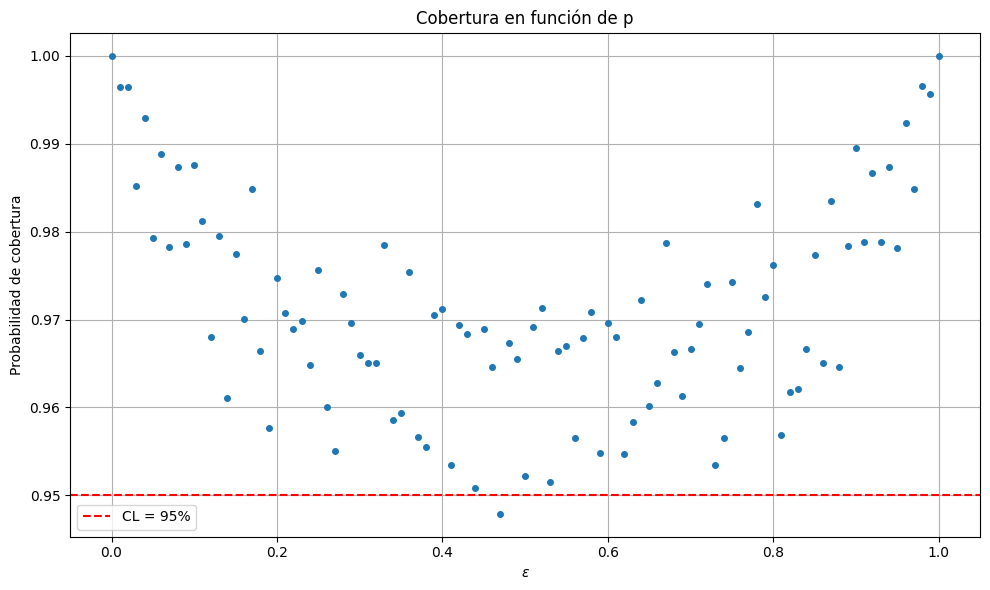

In [102]:
# Graficamos cobertura en funcion de p
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_title('Cobertura en función de p')
ax2.set_xlabel('$\\varepsilon$')
ax2.set_ylabel('Probabilidad de cobertura')
ax2.plot(vector_eps, coberturas_t, marker='o', linestyle='none', ms=4)
ax2.axhline(0.95, color='r', linestyle='--', label='CL = 95%')
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

## Conclusiones

Simulamos 10 000 experimentos de calibración de un detector con $n = 32$ partículas por experimento.

El **intervalo de Wald** tiene cobertura real inferior al 95% nominal en casi todo el rango de $\varepsilon$, con peor desempeño cerca de los extremos ($\varepsilon \approx 0$ o $\varepsilon \approx 1$). Esto ocurre porque la aproximación normal de la binomial falla cuando la distribución es asimétrica, que es justamente cuando el detector tiene eficiencia muy baja o muy alta.

El **intervalo de Agresti–Coull** logra una cobertura que en promedio supera el 95% nominal, siendo más conservador pero mucho más confiable. En experimentos de física de detectores, donde las eficiencias extremas son frecuentes, este intervalo es claramente preferible.